## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import warnings
from scipy import stats 


from flow_tree_utils import generate_traj_from_path, compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [2]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
test_df["accuracy"] = test_df["accuracy"].astype(bool)

test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
test_df["traj_strs"] = test_df["trajs"].apply("".join)


subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_test_df = pd.merge(test_df, subject_df, on="Subject")
# merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

## 3. Ego v allocentric encoding of trajectories

### Egocentric = Right, Left, Straight

In [39]:
def generate_egocentric_trajectories(path):
    egocentric_traj = []
    states = path.split()
    current_state = states[0] # Spatial, direction
    i = 1
    while i < len(states):
        next_state = states[i]

        same_place = next_state[0] == current_state[0]
        direction_diff = (int(next_state[1]) - int(current_state[1]))%4 # if same should be zero

        # if spatial location is different but orientation the same
        # THEY WENT STRAIGHT!
        if not same_place and direction_diff==0:
            egocentric_traj.append("F")
            current_state = next_state
            i += 1
        elif same_place and (direction_diff != 0):
            # 1 is up; 2 is right; 3 is down; 4 is left
            # so if next_dirr > current_dirr, means turn right
            if direction_diff == 1:
                egocentric_traj.append("R")
            elif direction_diff == 3:
                egocentric_traj.append("L")
            elif direction_diff == 2:
                egocentric_traj.append("U")
            else:
                print("Wrong turn", next_state, current_state,same_place, direction_diff)
                print("FUCK")
            current_state = next_state
            i+=1
        elif current_state==next_state:
            # stay
            egocentric_traj.append("S")
            current_state = next_state
            i+=1
        elif current_state=="X4" and next_state=="Z1":
            # weird maze coding
            egocentric_traj.append("F")
            current_state = next_state
            i+=1
        elif current_state=="Z1" and next_state=="P2":
            # weird maze coding
            egocentric_traj.append("F")
            current_state = next_state
            i+=1
        elif current_state=="P3" and next_state=="Z2":
            # weird maze coding
            egocentric_traj.append("F")
            current_state = next_state
            i+=1
        elif current_state=="M4" and next_state=="O2":
            # weird maze coding
            egocentric_traj.append("F")
            current_state = next_state
            i+=1
        elif current_state=="U2" and next_state=="W4":
            # weird maze coding
            egocentric_traj.append("F")
            current_state = next_state
            i+=1
        else:
            # other weird maze coding around objects
            egocentric_traj.append("F")
            current_state = next_state
            i+=1
    return egocentric_traj

merged_test_df["ego_trajs"] = merged_test_df["e_paths"].apply(generate_egocentric_trajectories)

In [41]:
def generate_alloentric_trajectories(path):
    # 1 is up; 2 is right; 3 is down; 4 is left
    dir_dict = {"1": "U", "2": "R", "3": "D", "4": "L"} 
            
    allocentric_traj = []
    states = path.split()
    current_state = states[0] # Spatial, direction
    i = 1
    while i < len(states):
        next_state = states[i]

        same_place = next_state[0] == current_state[0]
        direction_diff = (int(next_state[1]) - int(current_state[1]))%4 # if same should be zero

        # if spatial location is different but orientation the same
        # THEY WENT STRAIGHT!
        if not same_place and direction_diff==0:
            allocentric_traj.append(dir_dict[next_state[1]])
            current_state = next_state
            i += 1
        else:
            current_state = next_state
            i += 1
        
    return allocentric_traj

merged_test_df["allo_trajs"] = merged_test_df["e_paths"].apply(generate_alloentric_trajectories)

In [42]:
merged_test_df[["e_paths", "ego_trajs", "allo_trajs"]]

,e_paths,ego_trajs,allo_trajs
0,U4 U1 R1 J1 D1 D4 D3 D2 E2 F2 F3 F4 E4 D4 D3 J...,"[R, F, F, F, L, L, L, F, F, R, R, F, F, L, F, ...","[U, U, U, R, R, L, L, D]"
1,J4 J3 R3 U3 U4 T4 X4 Z1 P2 P2,"[L, F, F, R, F, F, F, F, S]","[D, D, L, L]"
2,P3 Z2 T2 T1 Q1 H1 H4 G4 G3 L3 L3,"[F, F, L, F, F, L, F, L, F, S]","[R, U, U, L, D]"
3,L1 G1 G2 H2 H1 B1 B2 C2 D2 E2 F2 F3 F4 E4 E3 M...,"[F, R, F, L, F, R, F, F, F, F, R, R, F, L, F, ...","[U, R, U, R, R, R, R, L, D]"
4,A3 G3 G2 H2 H1 B1 B2 C2 D2 E2 E3 E2 F2 F3 N3 N3,"[F, L, F, L, F, R, F, F, F, R, L, F, R, F, S]","[D, R, U, R, R, R, R, D]"
...,...,...,...
3399,Y4 V1 X1 Z1 P2 P3 Z2 T2 T1 Q1 H1 H4 G4 G1 A4,"[F, F, F, F, R, F, F, L, F, F, L, F, R, F]","[U, U, R, U, U, L]"
3400,M2 M1 E1 E4 E3 E2 F2 F3 N3 N3,"[L, F, L, L, L, F, R, F, S]","[U, R, D]"
3401,N1 F1 F4 E4 E3 M3 M4 M3 S3 S4 R4 R3 U3 U2 W4 W4,"[F, L, F, L, F, R, L, F, R, F, L, F, L, F, S]","[U, L, D, D, L, D]"
3402,M2 M1 E1 E2 E3 E4 D4 C4 C3 C4 B4 B3 H3 H4 H3 Q...,"[L, F, R, R, R, F, F, L, R, F, L, F, R, L, F, ...","[U, L, L, L, D, D, D]"


## 4. Generate Flow Trees

In [56]:
def cheap_gen_trajs(this_df, which_col):
    trajs = []
    for _, row in this_df.iterrows():
        if "" in (row[which_col]):
            print((row[which_col]))
        trajs.append(row[which_col])
    return trajs

acc_dict = {}
ego_tree_dict = {}
allo_tree_dict = {}
for (start_node, end_node), group in merged_test_df.groupby(["StartAt", "EndAt"]):
    acc_dict[(start_node, end_node)] = group["path_mean_acc"].iloc[0]

    ego_trajs = cheap_gen_trajs(group, "ego_trajs")
    G = generate_flow_tree_from_trajs(ego_trajs, END_NODE="?")
    ego_tree_dict[(start_node, end_node)] = G

    allo_trajs = cheap_gen_trajs(group, "allo_trajs")
    G = generate_flow_tree_from_trajs(allo_trajs, END_NODE="?")
    allo_tree_dict[(start_node, end_node)] = G


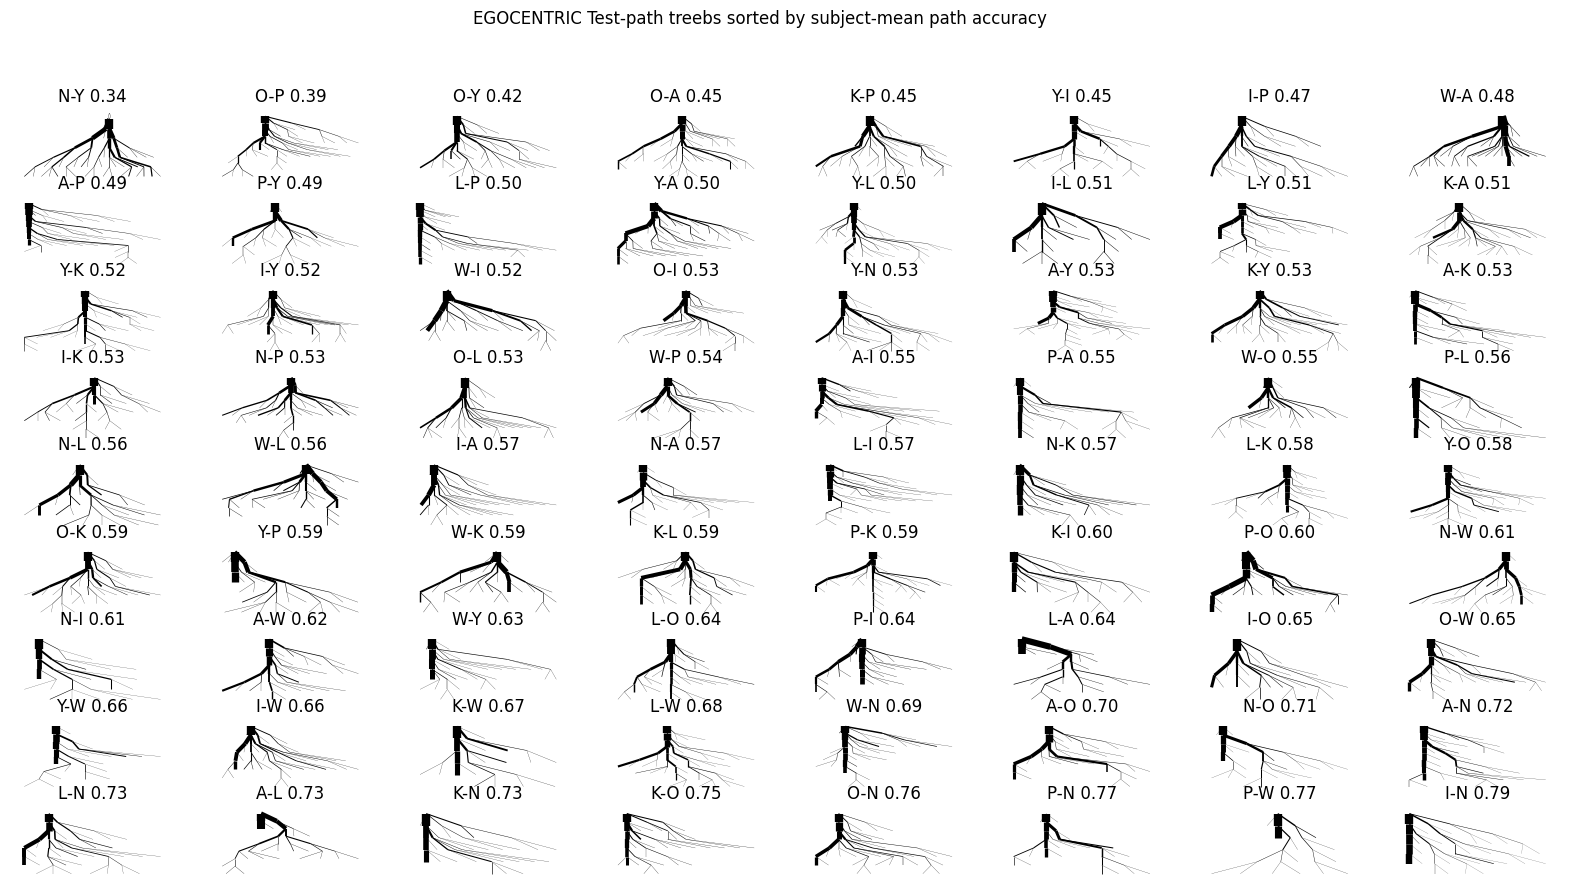

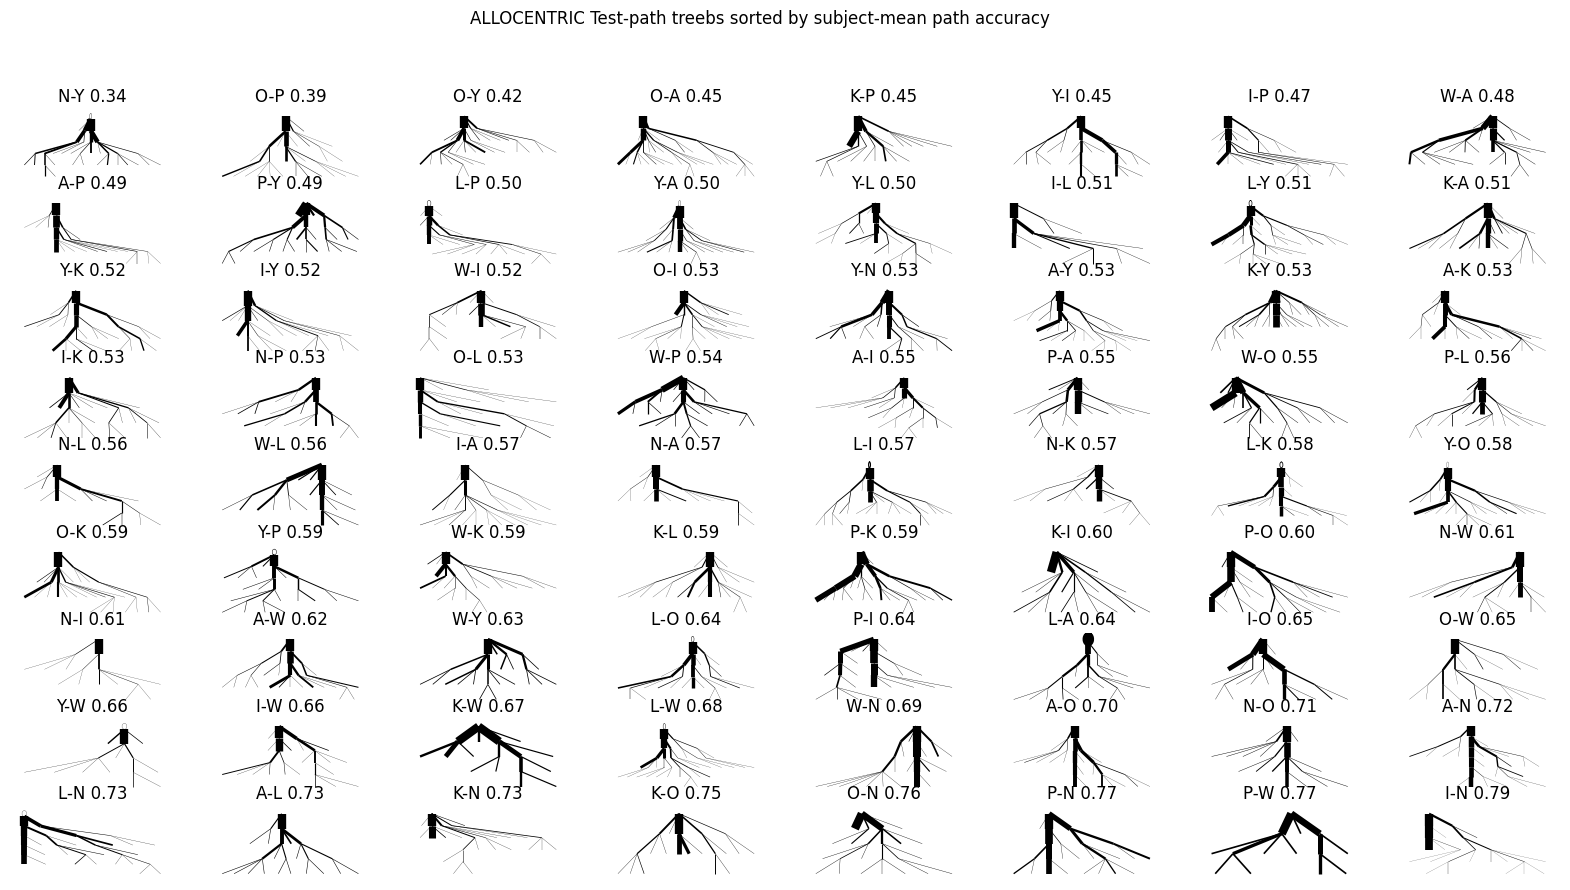

In [61]:
fig, axes = plt.subplots(9, 8, figsize=(20,10))


sorted_order = [k for k in sorted(acc_dict.keys(), key=lambda k: acc_dict[k])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = ego_tree_dict[tree_index]

    if "" in G.nodes():
        mapping = {"": "???"}
        G = nx.relabel_nodes(G, mapping)

    ax = axes[i // 8][i % 8]
    plot_flow_tree(G, f"{'-'.join(tree_index)} {acc_dict[tree_index]:.2f}", ax, just_edges=True)

fig.suptitle("EGOCENTRIC Test-path treebs sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc-egocentric.png")

plt.show()


fig, axes = plt.subplots(9, 8, figsize=(20,10))

c=0
for i, tree_index in enumerate(sorted_order):
    G = allo_tree_dict[tree_index]

    if "" in G.nodes():
        mapping = {"": "???"}
        G = nx.relabel_nodes(G, mapping)

    ax = axes[i // 8][i % 8]
    plot_flow_tree(G, f"{'-'.join(tree_index)} {acc_dict[tree_index]:.2f}", ax, just_edges=True)

fig.suptitle("ALLOCENTRIC Test-path treebs sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc-allocentric.png")

plt.show()


# compare to baseline
#   of min path distance!

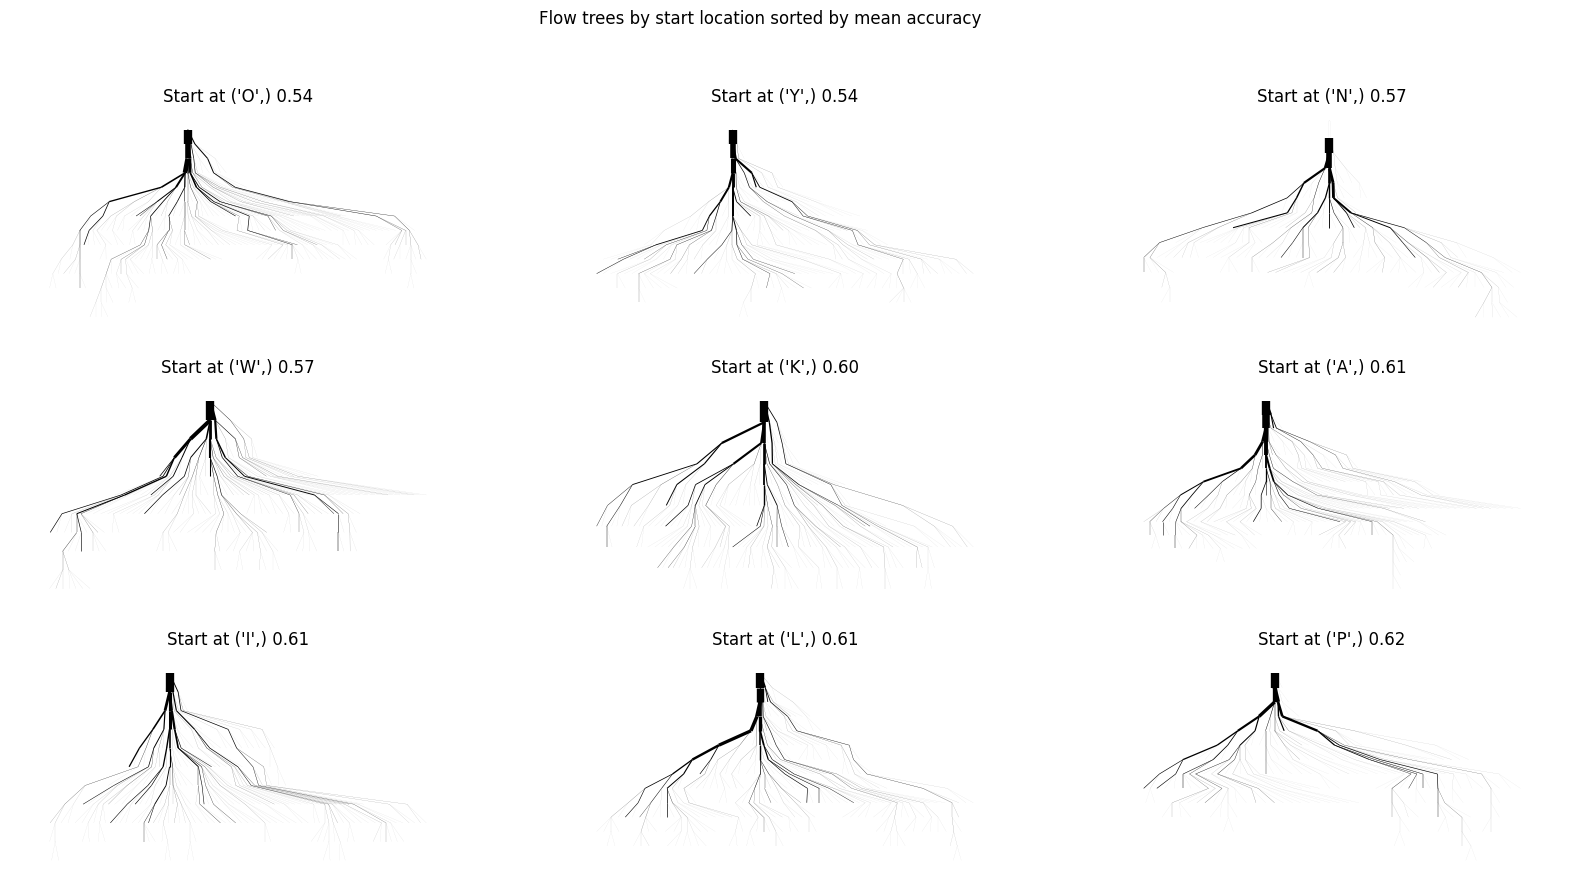

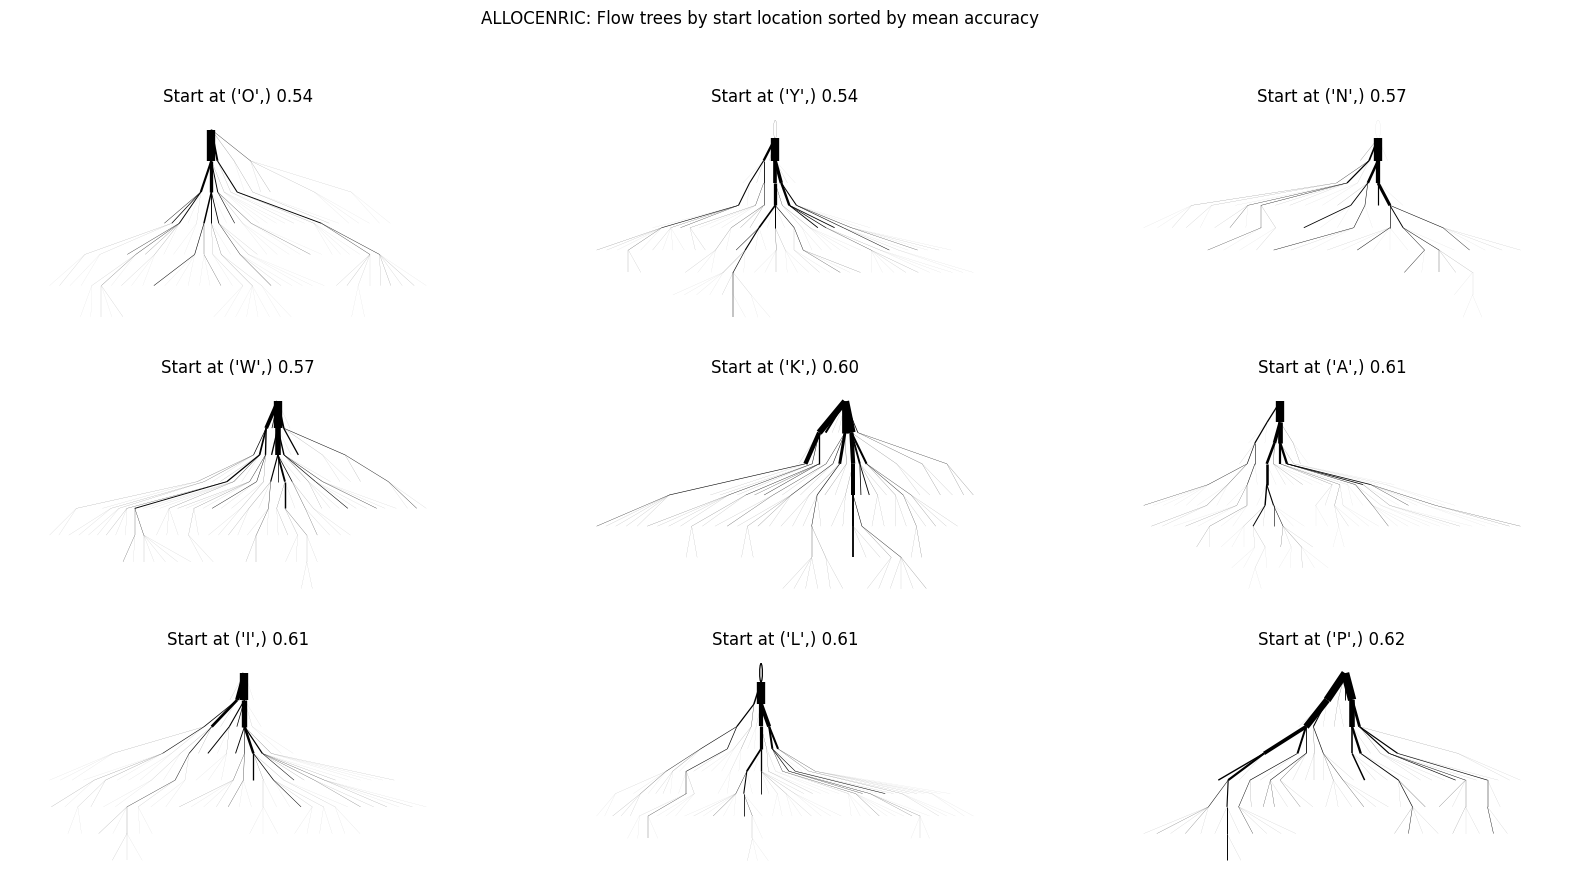

In [60]:
## BY START
ego_start_tree_dict = {}
for start_node, group in merged_test_df.groupby(["StartAt"]):
    ego_trajs = cheap_gen_trajs(group, "ego_trajs")
    G = generate_flow_tree_from_trajs(ego_trajs, END_NODE="1")#end_node)

    if "" in G.nodes():
        mapping = {"": "???"}
        G = nx.relabel_nodes(G, mapping)

    ego_start_tree_dict[start_node] = [G, np.mean(group["path_mean_acc"])]

# Allocentric
allo_start_tree_dict = {}
for start_node, group in merged_test_df.groupby(["StartAt"]):
    allo_trajs = cheap_gen_trajs(group, "allo_trajs")
    G = generate_flow_tree_from_trajs(allo_trajs, END_NODE="1")
    if "" in G.nodes():
        mapping = {"": "???"}
        G = nx.relabel_nodes(G, mapping)

    allo_start_tree_dict[start_node] = [G, np.mean(group["path_mean_acc"])]

# Plot all trajectories
start_accs = [v[1] for v in ego_start_tree_dict.values()]
start_graphs = [v[0] for v in ego_start_tree_dict.values()]
start_nodes = list(ego_start_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
sorted_order = [x for x in sorted(range(len(start_accs)), key=lambda x: start_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = start_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    plot_flow_tree(G, f"Start at {start_nodes[tree_index]} {start_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("Flow trees by start location sorted by mean accuracy")
fig.savefig("figures/start_flow_trees_by_acc-EGO.png")
plt.show()

# Plot winners
start_winner_accs = [v[1] for v in allo_start_tree_dict.values()]
start_winner_graphs = [v[0] for v in allo_start_tree_dict.values()]
start_winner_nodes = list(allo_start_tree_dict.keys())

fig, axes = plt.subplots(3, 3, figsize=(20,10))
# sorted_order = [x for x in sorted(range(len(start_winner_accs)), key=lambda x: start_winner_accs[x])]
for i, tree_index in enumerate(sorted_order):
    G = start_winner_graphs[tree_index]
    ax = axes[i // 3][i % 3]
    plot_flow_tree(G, f"Start at {start_winner_nodes[tree_index]} {start_winner_accs[tree_index]:.2f}", ax, just_edges=True)
fig.suptitle("ALLOCENRIC: Flow trees by start location sorted by mean accuracy") 
fig.savefig("figures/start_flow_trees_by_acc-ALLO.png")
plt.show()


# canyou gather people's intention from here? like look at subtrees and cluster???
# real human movement